# 05B - Bounds Stress Test Error Analysis for 1000 expanded factor (1-2, 0.25 step size) simulations

The purpose of this notebook is to identify, analyze, and inspect the bounds for the tunable parameters. 

### Merge Dataset



In [1]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd().parents[0]   # adjust if needed

csv_path = (
    ROOT
    / "01_Data"
    / "simulation_results"
    / "pediatric_dcm_patient_01"
    / "expansion_stress_test_1000"
    / "merged_all_results.csv"
)

df = pd.read_csv(csv_path)

tunables = [
    "expansion_factor",
    "k_Vtot",
    "k_Vsys",
    "k_Vusv_sys",
    "k_Vusv_sys_ven",
    "k_Vusv_pulm_ven",
    "k_Ctot",
    "k_Csys",
    "k_Rsysven",
    "k_Rpulmart",
    "k_ESP_LV",
    "k_ESP_RV",
]

failed = df[df["simulation_status"] == "failed"]
success = df[df["simulation_status"] == "success"]

print("Loaded:", csv_path)
print("Total:", len(df))
print("Success:", len(success))
print("Failed:", len(failed))
print("Failure rate:", len(failed) / len(df) * 100, "%")

print("\nFailed cases:")
print(failed[["simulation_id"] + tunables])

print("\nMean tunables: success vs failed")
print(df.groupby("simulation_status")[tunables].mean())

print("\nMin/max tunables in failed cases")
print(failed[tunables].describe().T)

Loaded: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\simulation_results\pediatric_dcm_patient_01\expansion_stress_test_1000\merged_all_results.csv
Total: 965
Success: 869
Failed: 96
Failure rate: 9.94818652849741 %

Failed cases:
     simulation_id  expansion_factor      k_Vtot    k_Vsys  k_Vusv_sys  \
251            262               1.5   73.244232  0.722339    0.723556   
261            272               1.5   89.978296  0.861998    0.961907   
264            275               1.5   72.239313  0.615395    0.653840   
274            310               1.5   83.172616  0.919125    0.776466   
282            318               1.5   58.604595  0.763091    0.962893   
..             ...               ...         ...       ...         ...   
954            990               2.0   78.035754  1.221087    0.514261   
955            991               2.0  113.462433  0.830116    0.925377   
956            992               2.0   85.405795  0.431643    0.918898 

The failure rate of 10% is completly acceptable for an expansion test. However, there is already a clear insight from the reults. K_Csys is clearly the dominant instability driver. Succesful runs average 0.81 and almost all failures happen near or above 1.0. This signifies that the model has a real physiological/numerical boundary here. 

This insight corresponds to the expected physiological results. Physiologically we already know that: 

Csys = k_Csys * Ctot 

Cpulm = Ctot-Csys

So when Csys=1, then Csys=Ctot => Cpulm = 0. This is very bad as physiologically this means that pulmonary circulation becomes almost non-compliant. Tiny volume changes create huge pressure changes. 

Numerically, the system becomes extremely stiff. Pressure derivatives explode resulting in the SImulink solvers struggling and eventually step size collapses and integration fails. 

Based on these results, we can already conclude that k_Csys should not be bigger then 0.95. 

In [18]:
# ------------------------------------------------------------
# 1. Lowest k_Csys where a failure occurs
# ------------------------------------------------------------

lowest_failed_kcsys = failed["k_Csys"].min()

print("Lowest failed k_Csys:", lowest_failed_kcsys)

# ------------------------------------------------------------
# 2. Successful simulations ABOVE that threshold
# ------------------------------------------------------------

success_above_threshold = success[
    success["k_Csys"] >= lowest_failed_kcsys
]

print(
    "\nSuccessful simulations with k_Csys >= lowest failed value:"
)

print(len(success_above_threshold))

# ------------------------------------------------------------
# 3. Display them
# ------------------------------------------------------------

display(
    success_above_threshold[
        [
            "simulation_id",
            "k_Csys",
            "simulation_status",
        ]
    ].sort_values("k_Csys")
)

Lowest failed k_Csys: 0.974626251911481

Successful simulations with k_Csys >= lowest failed value:
88


,simulation_id,k_Csys,simulation_status
866,902,0.975266,success
369,405,0.975956,success
338,374,0.976575,success
741,777,0.977268,success
250,261,0.979135,success
...,...,...,...
758,794,1.231085,success
765,801,1.232207,success
822,858,1.236424,success
894,930,1.239791,success


In [19]:
# ------------------------------------------------------------
# Failure rate above threshold
# ------------------------------------------------------------

all_above_threshold = df[
    df["k_Csys"] >= lowest_failed_kcsys
]

n_total = len(all_above_threshold)

n_failed = len(
    all_above_threshold[
        all_above_threshold["simulation_status"] == "failed"
    ]
)

failure_rate = 100 * n_failed / n_total

print("\nAbove threshold:")
print("Total sims:", n_total)
print("Failed sims:", n_failed)
print("Failure rate:", round(failure_rate, 2), "%")


Above threshold:
Total sims: 184
Failed sims: 96
Failure rate: 52.17 %


In [20]:
df["Cpulm_fraction"] = 1 - df["k_Csys"]

display(
    df[
        [
            "simulation_id",
            "simulation_status",
            "k_Csys",
            "Cpulm_fraction",
        ]
    ].sort_values("k_Csys", ascending=False)
)

,simulation_id,simulation_status,k_Csys,Cpulm_fraction
844,880,success,1.242882,-0.242882
894,930,success,1.239791,-0.239791
822,858,success,1.236424,-0.236424
765,801,success,1.232207,-0.232207
758,794,success,1.231085,-0.231085
...,...,...,...,...
901,937,success,0.429663,0.570337
851,887,success,0.425877,0.574123
917,953,success,0.421879,0.578121
895,931,success,0.421579,0.578421


These results confirm that 0.95 is a more then an acceptable upper bound for K_Csys. All successes where k_Csys is over 1 will be disgarded as they are not physiologically meaningful. This is confirmed by the resulting negative pulmonary compliance fraction. 

### Comparing succesful vs failed tunables:

In [17]:
rows = []

for var in tunables:

    success_values = success[var]
    failed_values = failed[var]

    rows.append({
        "variable": var,

        "success_mean": success_values.mean(),
        "failed_mean": failed_values.mean(),

        "success_std": success_values.std(),
        "failed_std": failed_values.std(),

        "success_min": success_values.min(),
        "failed_min": failed_values.min(),

        "success_max": success_values.max(),
        "failed_max": failed_values.max(),

        "mean_difference": (
            failed_values.mean() - success_values.mean()
        ),
    })

comparison_df = pd.DataFrame(rows)

comparison_df = comparison_df.sort_values(
    "mean_difference",
    key=abs,
    ascending=False
)

display(comparison_df)

,variable,success_mean,failed_mean,success_std,failed_std,success_min,failed_min,success_max,failed_max,mean_difference
1,k_Vtot,76.821747,79.131913,15.274754,16.226694,38.538493,44.835543,115.316193,113.462433,2.310166
7,k_Csys,0.808066,1.026634,0.160466,0.034103,0.416600,0.974626,1.242882,1.150913,0.218568
0,expansion_factor,1.619102,1.750000,0.286099,0.198680,1.250000,1.500000,2.000000,2.000000,0.130898
6,k_Ctot,2.161932,2.032261,0.421090,0.485084,1.077996,1.165613,3.216413,3.066550,-0.129671
11,k_ESP_RV,0.905329,0.852476,0.177691,0.191899,0.452617,0.464134,1.346553,1.319792,-0.052853
9,k_Rpulmart,0.632751,0.607661,0.124393,0.134806,0.318535,0.315723,0.943666,0.930416,-0.025090
3,k_Vusv_sys,0.818342,0.836804,0.162626,0.175080,0.411739,0.458291,1.227772,1.221370,0.018462
4,k_Vusv_sys_ven,0.931820,0.921888,0.183273,0.205429,0.467924,0.468938,1.394507,1.351466,-0.009932
2,k_Vsys,0.818734,0.828580,0.161297,0.186772,0.411827,0.417673,1.228732,1.226434,0.009846
8,k_Rsysven,0.060240,0.057900,0.011891,0.012695,0.030218,0.030390,0.089876,0.088922,-0.002340


Other tunable parameters such as k_Vtot, k_Vsys, k_ESP_LV, and k_Rsysven showed substantial overlap between successful and failed simulations. Although some variables displayed moderate shifts in their mean values, none exhibited the same sharp concentration pattern observed for k_Csys. This indicates that these parameters may influence the physiological outputs of the model, but are not primary drivers of numerical instability.

Overall, this analysis suggests that the cardiovascular model is globally robust across most of the explored parameter space, with instability occurring mainly in regions associated with excessively high values of k_Csys

### Failure rate by parameter bins 

In [21]:
bin_results = []

for var in tunables:
    temp = df[[var, "simulation_status"]].dropna().copy()

    temp["bin"] = pd.qcut(
        temp[var],
        q=10,
        duplicates="drop"
    )

    grouped = temp.groupby("bin", observed=True).agg(
        total=("simulation_status", "count"),
        failed=("simulation_status", lambda x: (x == "failed").sum()),
    )

    grouped["failure_rate_%"] = 100 * grouped["failed"] / grouped["total"]
    grouped["variable"] = var

    bin_results.append(grouped.reset_index())

failure_bins = pd.concat(bin_results, ignore_index=True)

# Show only k_Csys bins
display(
    failure_bins[failure_bins["variable"] == "k_Csys"]
    .sort_values("bin")
)

,bin,total,failed,failure_rate_%,variable
63,"(0.416, 0.613]",97,0,0.000000,k_Csys
64,"(0.613, 0.693]",96,0,0.000000,k_Csys
65,"(0.693, 0.749]",97,0,0.000000,k_Csys
66,"(0.749, 0.788]",96,0,0.000000,k_Csys
67,"(0.788, 0.83]",97,0,0.000000,k_Csys
68,"(0.83, 0.871]",96,0,0.000000,k_Csys
69,"(0.871, 0.911]",96,0,0.000000,k_Csys
70,"(0.911, 0.967]",97,0,0.000000,k_Csys
71,"(0.967, 1.047]",96,76,79.166667,k_Csys
72,"(1.047, 1.243]",97,20,20.618557,k_Csys


This analysis furthur confirms that k_Csys is the dominant instability-driving parameter of the model and identifies the region near k_Csys ≈ 1 as the primary instability zone.

### Dangerous regions 

In [22]:
danger_zones = failure_bins[failure_bins["failure_rate_%"] > 20]

display(
    danger_zones.sort_values(
        "failure_rate_%",
        ascending=False
    )
)

,bin,total,failed,failure_rate_%,variable
71,"(0.967, 1.047]",96,76,79.166667,k_Csys
53,"(1.0770000000000002, 1.586]",97,22,22.680412,k_Ctot
72,"(1.047, 1.243]",97,20,20.618557,k_Csys


### Succes vs failed for each tunable 

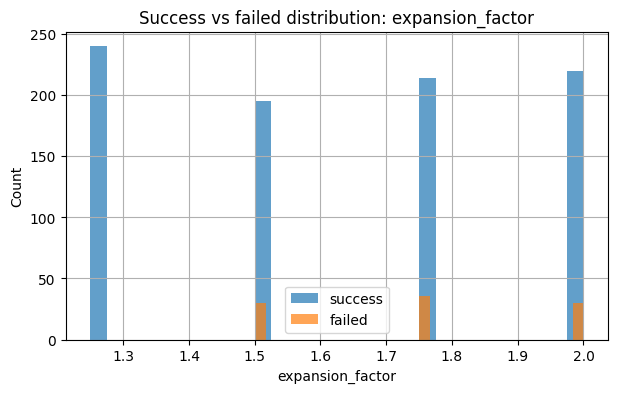

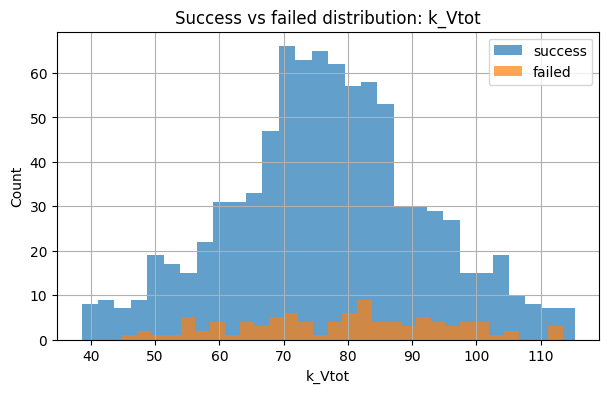

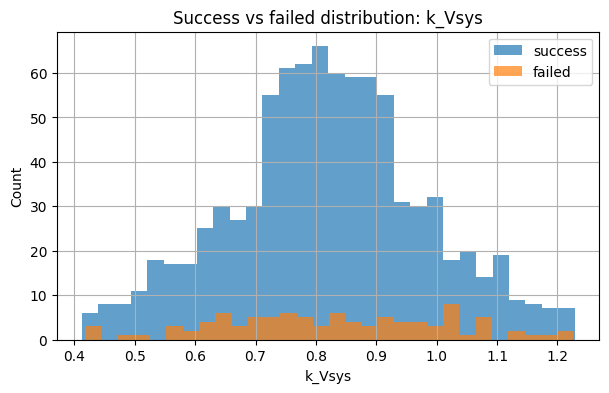

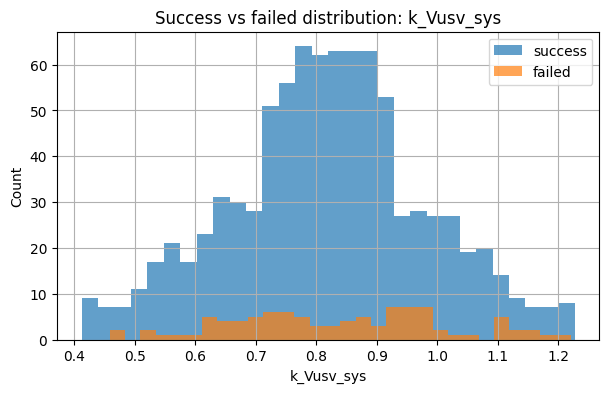

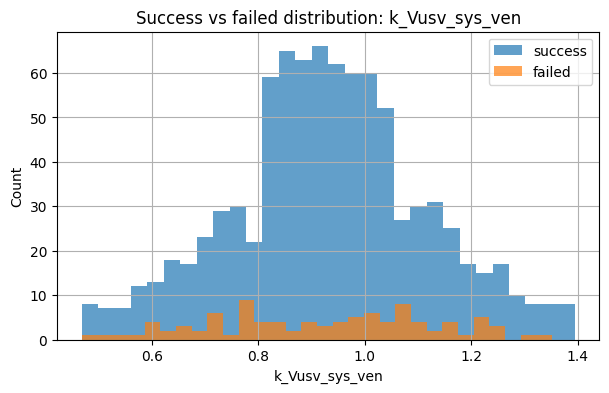

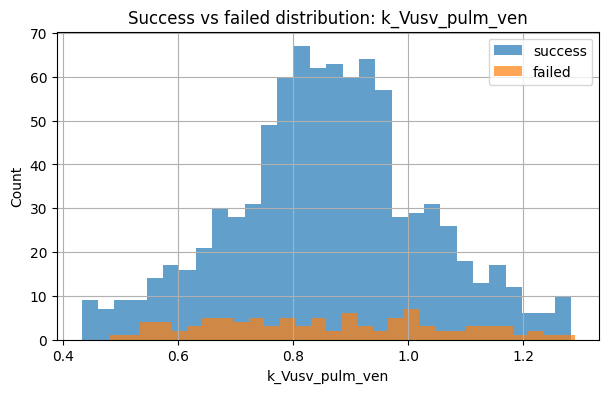

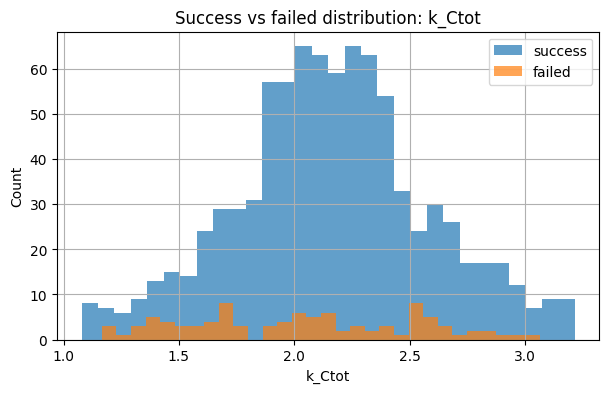

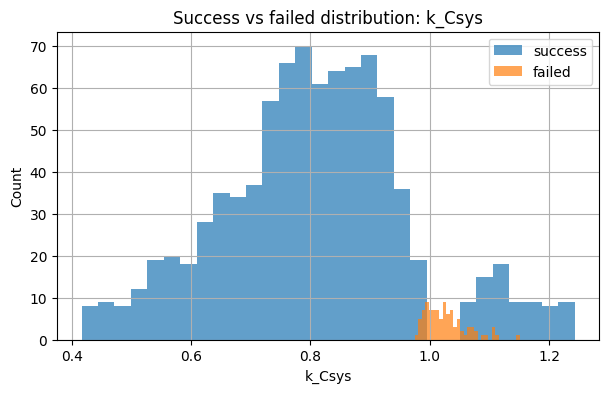

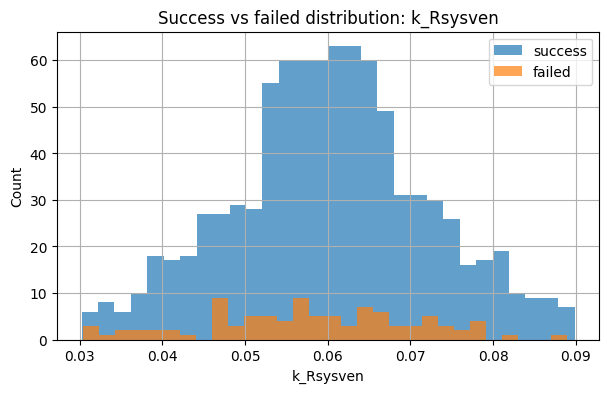

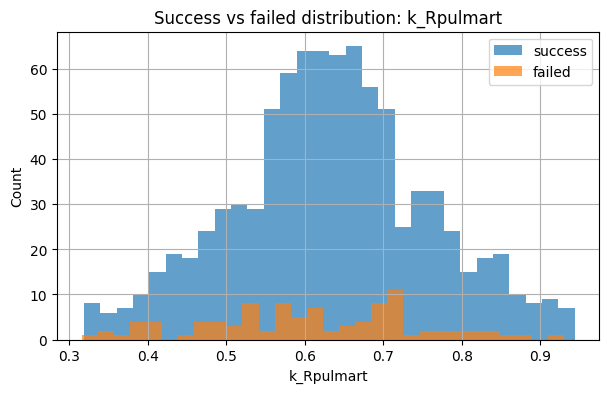

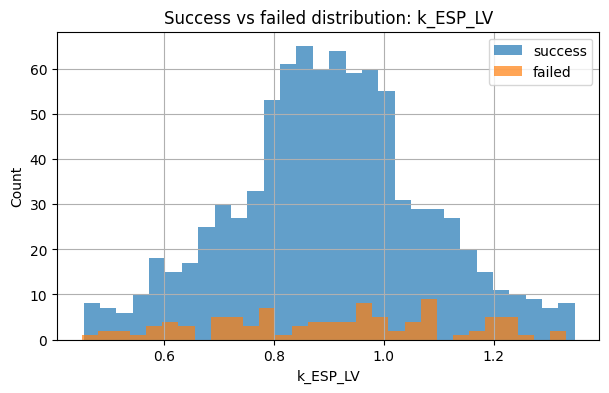

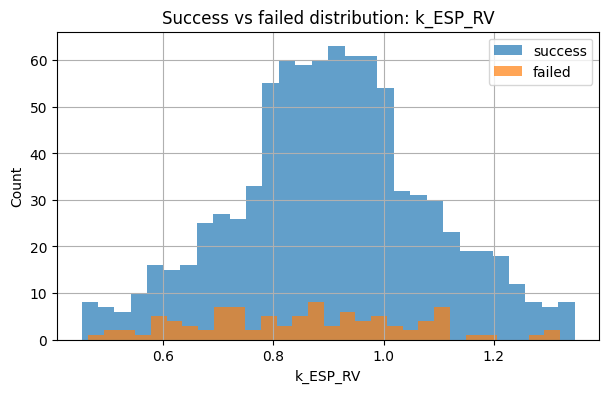

In [13]:
import matplotlib.pyplot as plt

for var in tunables:
    plt.figure(figsize=(7, 4))

    success[var].hist(alpha=0.7, bins=30, label="success")
    failed[var].hist(alpha=0.7, bins=30, label="failed")

    plt.title(f"Success vs failed distribution: {var}")
    plt.xlabel(var)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

The histogram comparison further confirms that k_Csys is the primary instability-driving parameter in the explored parameter space. The failed simulations are highly concentrated in a narrow region around k_Csys ≈ 1, while successful simulations dominate the lower ranges of the distribution. This sharp separation between successful and failed cases indicates the existence of a clear stability threshold associated with systemic compliance allocation.

In contrast, the distributions of the other tunable parameters, such as k_Rsysven, do not exhibit a distinct separation between successful and failed simulations. The failed cases remain scattered throughout the entire parameter range and generally follow the same distribution shape as the successful simulations. This suggests that these parameters are not direct causes of instability, but rather secondary variables whose influence depends on interactions with the global system state.

Overall, the distribution analysis strongly supports the conclusion that the model instability is primarily linked to excessively high values of k_Csys, whereas the remaining tunable parameters appear comparatively robust within the explored bounds.

### Errors by type 

In [26]:
from pathlib import Path
import pandas as pd
import re

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

ROOT = Path.cwd().parents[0]

errors_dir = (
    ROOT
    / "01_Data"
    / "simulation_results"
    / "pediatric_dcm_patient_01"
    / "errors"
)

# ------------------------------------------------------------
# 2. Normalize error text
# ------------------------------------------------------------

def normalize_error(text: str) -> str:
    text = text.strip()

    if "Caused by:" in text:
        text = text.split("Caused by:", 1)[1]

    text = re.sub(
        r"at time\s+[0-9]+(?:\.[0-9]+)?(?:[Ee][+-]?[0-9]+)?",
        "at time <TIME>",
        text,
    )

    text = re.sub(
        r"hmin\s*\([0-9.Ee+-]+\)",
        "hmin(<HMIN>)",
        text,
    )

    text = re.sub(
        r"line\s+\d+",
        "line <LINE>",
        text,
    )

    text = re.sub(r"\s+", " ", text)

    return text.strip()

# ------------------------------------------------------------
# 3. Classify error category
# ------------------------------------------------------------

def classify_error(text: str) -> str:
    text_lower = text.lower()

    if "nonlinear iteration is not converging" in text_lower:
        return "nonlinear_iteration_hmin"

    if "an internal error has occurred" in text_lower:
        return "matlab_internal_error"

    if "derivative" in text_lower and "not finite" in text_lower:
        return "non_finite_derivative"

    if "algebraic loop" in text_lower:
        return "algebraic_loop"

    if "division by zero" in text_lower:
        return "division_by_zero"

    if "unrecognized function or variable" in text_lower:
        return "missing_variable"

    return "other"

# ------------------------------------------------------------
# 4. Read all txt error files
# ------------------------------------------------------------

records = []

txt_files = sorted(errors_dir.glob("*.txt"))

print("Error files found:", len(txt_files))

for path in txt_files:
    raw_text = path.read_text(
        encoding="utf-8",
        errors="ignore"
    )

    normalized = normalize_error(raw_text)
    category = classify_error(normalized)

    simulation_id_match = re.search(r"simulation_(\d+)", path.stem)

    if simulation_id_match:
        simulation_id = int(simulation_id_match.group(1))
    else:
        simulation_id = None

    records.append({
        "simulation_id": simulation_id,
        "file": path.name,
        "error_category": category,
        "normalized_error": normalized,
    })

errors_df = pd.DataFrame(records)

# ------------------------------------------------------------
# 5. Summary by error category
# ------------------------------------------------------------

category_summary = (
    errors_df.groupby("error_category")
    .agg(
        count=("file", "count"),
        example_file=("file", "first"),
    )
    .reset_index()
    .sort_values("count", ascending=False)
)

category_summary["percentage"] = (
    100 * category_summary["count"] / category_summary["count"].sum()
).round(2)

display(category_summary)

# ------------------------------------------------------------
# 6. Detailed normalized error summary
# ------------------------------------------------------------

normalized_summary = (
    errors_df.groupby(["error_category", "normalized_error"])
    .agg(
        count=("file", "count"),
        example_file=("file", "first"),
    )
    .reset_index()
    .sort_values("count", ascending=False)
)

normalized_summary["percentage"] = (
    100 * normalized_summary["count"] / normalized_summary["count"].sum()
).round(2)

pd.set_option("display.max_colwidth", None)

display(normalized_summary)

# ------------------------------------------------------------
# 7. Show examples per category
# ------------------------------------------------------------

for category in errors_df["error_category"].unique():
    print("\n" + "=" * 80)
    print("CATEGORY:", category)
    print("=" * 80)

    example = errors_df[errors_df["error_category"] == category].iloc[0]

    print("Example file:", example["file"])
    print()
    print(example["normalized_error"])

Error files found: 133


,error_category,count,example_file,percentage
1,nonlinear_iteration_hmin,107,simulation_1000_error.txt,80.45
0,matlab_internal_error,26,simulation_367_error.txt,19.55


,error_category,normalized_error,count,example_file,percentage
2,nonlinear_iteration_hmin,"Error using run_one_case_pediatric_noVAD_linear (line <LINE>) Nonlinear iteration is not converging with step size reduced to hmin(<HMIN>) at time <TIME>. Try reducing the minimum step size and/or relax the relative error tolerance. Error in run_parallel_expansion_stress_test_pediatric_noVAD_linear (line <LINE>) raw_result = run_one_case_pediatric_noVAD_linear(sample_row, model); ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^",101,simulation_1000_error.txt,75.94
0,matlab_internal_error,"Error using run_one_case_pediatric_noVAD_linear (line <LINE>) An internal error has occurred. Restart MATLAB before proceeding. If this problem persists, please contact MathWorks. Error in run_parallel_expansion_stress_test_pediatric_noVAD_linear (line <LINE>) raw_result = run_one_case_pediatric_noVAD_linear(sample_row, model); ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^",26,simulation_367_error.txt,19.55
1,nonlinear_iteration_hmin,"Error using run_one_case_pediatric_noVAD_linear (line <LINE>) Nonlinear iteration is not converging with step size reduced to hmin(<HMIN>) at time <TIME>. Try reducing the minimum step size and/or relax the relative error tolerance. Error in run_bounds_stress_test_pediatric_noVAD_linear (line <LINE>) result_row = run_one_case_pediatric_noVAD_linear(sample_row, model); ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^",6,simulation_104_error.txt,4.51



CATEGORY: nonlinear_iteration_hmin
Example file: simulation_1000_error.txt

Error using run_one_case_pediatric_noVAD_linear (line <LINE>) Nonlinear iteration is not converging with step size reduced to hmin(<HMIN>) at time <TIME>. Try reducing the minimum step size and/or relax the relative error tolerance. Error in run_parallel_expansion_stress_test_pediatric_noVAD_linear (line <LINE>) raw_result = run_one_case_pediatric_noVAD_linear(sample_row, model); ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

CATEGORY: matlab_internal_error
Example file: simulation_367_error.txt

Error using run_one_case_pediatric_noVAD_linear (line <LINE>) An internal error has occurred. Restart MATLAB before proceeding. If this problem persists, please contact MathWorks. Error in run_parallel_expansion_stress_test_pediatric_noVAD_linear (line <LINE>) raw_result = run_one_case_pediatric_noVAD_linear(sample_row, model); ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

### Are all errors due to K_Csys? 

In [27]:
# ------------------------------------------------------------
# Check how many error simulations have k_Csys > 0.95
# ------------------------------------------------------------

from pathlib import Path
import pandas as pd
import re

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

ROOT = Path.cwd().parents[0]

errors_dir = (
    ROOT
    / "01_Data"
    / "simulation_results"
    / "pediatric_dcm_patient_01"
    / "errors"
)

merged_results_path = (
    ROOT
    / "01_Data"
    / "simulation_results"
    / "pediatric_dcm_patient_01"
    / "expansion_stress_test_1000"
    / "merged_all_results.csv"
)

# ------------------------------------------------------------
# 2. Load merged simulation dataframe
# ------------------------------------------------------------

df = pd.read_csv(merged_results_path)

# ------------------------------------------------------------
# 3. Extract simulation IDs from error files
# ------------------------------------------------------------

error_simulation_ids = []

for path in sorted(errors_dir.glob("*.txt")):

    match = re.search(r"simulation_(\d+)", path.stem)

    if match:
        simulation_id = int(match.group(1))
        error_simulation_ids.append(simulation_id)

# Remove duplicates
error_simulation_ids = list(set(error_simulation_ids))

print("Total unique error simulations:", len(error_simulation_ids))

# ------------------------------------------------------------
# 4. Get corresponding simulation rows
# ------------------------------------------------------------

error_df = df[
    df["simulation_id"].isin(error_simulation_ids)
].copy()

print("Matched error simulations:", len(error_df))

# ------------------------------------------------------------
# 5. Check k_Csys threshold
# ------------------------------------------------------------

threshold = 0.95

high_kcsys_errors = error_df[
    error_df["k_Csys"] > threshold
]

n_high = len(high_kcsys_errors)
n_total = len(error_df)

percentage = 100 * n_high / n_total

print("\n================================================")
print("k_Csys ERROR ANALYSIS")
print("================================================")

print(f"Threshold: k_Csys > {threshold}")
print(f"Errors above threshold: {n_high}")
print(f"Total errors: {n_total}")
print(f"Percentage: {percentage:.2f}%")

# ------------------------------------------------------------
# 6. Display simulations BELOW threshold
# ------------------------------------------------------------

below_threshold = error_df[
    error_df["k_Csys"] <= threshold
]

print("\n================================================")
print("ERRORS WITH k_Csys <= THRESHOLD")
print("================================================")

print("Count:", len(below_threshold))

display(
    below_threshold[
        [
            "simulation_id",
            "k_Csys",
            "k_Ctot",
            "k_Rsysven",
            "k_Rpulmart",
            "k_ESP_LV",
            "k_ESP_RV",
        ]
    ].sort_values("k_Csys")
)

Total unique error simulations: 133
Matched error simulations: 132

k_Csys ERROR ANALYSIS
Threshold: k_Csys > 0.95
Errors above threshold: 99
Total errors: 132
Percentage: 75.00%

ERRORS WITH k_Csys <= THRESHOLD
Count: 33


,simulation_id,k_Csys,k_Ctot,k_Rsysven,k_Rpulmart,k_ESP_LV,k_ESP_RV
349,385,0.626095,2.649212,0.060771,0.623335,0.784439,0.860496
331,367,0.646645,1.977785,0.060176,0.743922,0.846748,0.772745
344,380,0.659560,2.380167,0.047998,0.584973,0.832612,0.999874
348,384,0.663064,1.660223,0.059586,0.665247,0.959652,0.689670
336,372,0.690367,1.680408,0.064255,0.738659,0.817632,1.097439
337,373,0.691730,1.721958,0.057660,0.656577,0.816425,1.033857
335,371,0.700490,1.682727,0.061613,0.654200,0.678614,0.777940
346,382,0.705567,2.215896,0.065432,0.764959,0.884415,0.888075
360,396,0.713447,2.457857,0.073118,0.677467,0.773689,0.735983
350,386,0.716458,2.441909,0.059020,0.525684,0.835493,0.827933


The analysis of the remaining failed simulations with k_Csys <= 0.95 shows that not all model instabilities are exclusively caused by high values of k_Csys. Although the majority of failures were associated with k_Csys approaching or exceeding 1.0, a smaller subset of simulations still failed within lower and physiologically acceptable ranges of systemic compliance distribution.

The failed cases presented above exhibit relatively broad distributions for the remaining tunable parameters, suggesting that these failures are likely caused by parameter interactions rather than by a single dominant instability threshold. In particular, several simulations display relatively low values of k_Rpulmart, often in the range of approximately 0.50–0.65. This may indicate that reduced pulmonary arterial resistance contributes to instability by decreasing damping in the pulmonary circulation and increasing sensitivity of the right ventricular–pulmonary coupling.

In addition, some failed cases also exhibit elevated ventricular elastance parameters (k_ESP_LV and k_ESP_RV), particularly for the right ventricle. Higher elastance values increase ventricular stiffness and may amplify pressure oscillations or nonlinear behavior within the cardiovascular system. Combined with low pulmonary resistance or altered compliance distributions, these parameter interactions can create locally stiff numerical conditions that are difficult for the solver to integrate.

Another important observation is that several of these failed simulations are clustered within nearby simulation indices, which may suggest that part of these failures are related to MATLAB or Simulink internal instability after repeated solver crashes rather than purely physiological model instability. This interpretation is supported by the previous error classification, where a subset of errors corresponded to MATLAB internal errors rather than direct nonlinear convergence failures.

Overall, these results suggest that k_Csys remains the primary instability-driving parameter of the model, explaining approximately 75% of all recorded errors. However, secondary instability mechanisms also exist and appear to involve interactions between pulmonary resistance, ventricular elastance, and compliance-related parameters.

In [28]:
stage_1_bounds = pd.DataFrame([
    ["k_Vtot", 67.5, 60.0, 85.0, "Total blood volume coefficient; pediatric range should be validated"],
    ["k_Vsys", 0.84, 0.75, 0.90, "Fraction of total blood volume in systemic circulation"],
    ["k_Vusv_sys", 0.84, 0.75, 0.90, "Fraction of unstressed volume in systemic circulation"],
    ["k_Vusv_sys_ven", 0.95, 0.90, 0.99, "Fraction of systemic unstressed volume assigned to venous compartment"],
    ["k_Vusv_pulm_ven", 0.90, 0.80, 0.97, "Fraction of pulmonary unstressed volume assigned to pulmonary compartment"],
    ["k_Ctot", 2.15, 1.72, 2.58, "±20% around baseline total vascular compliance coefficient"],
    ["k_Csys", 0.85, 0.75, 0.95, "Fraction of total vascular compliance assigned to systemic circulation"],
    ["k_Rsysven", 60/1000, 0.048, 0.072, "±20% around systemic venous resistance scaling coefficient"],
    ["k_Rpulmart", 2/3, 0.50, 0.80, "Fraction of total pulmonary resistance assigned to pulmonary arterial resistance"],
    ["k_ESP_LV", 0.90, 0.75, 1.05, "LV end-systolic pressure fraction of systemic systolic pressure"],
    ["k_ESP_RV", 0.90, 0.75, 1.05, "RV end-systolic pressure fraction of systolic pulmonary arterial pressure"],
], columns=["variable", "baseline", "lower_bound", "upper_bound", "bound_reason"])

# ------------------------------------------------------------
# 1. Build baseline dictionary from stage_1_bounds
# ------------------------------------------------------------

baseline = dict(
    zip(
        stage_1_bounds["variable"],
        stage_1_bounds["baseline"]
    )
)

tunables = list(baseline.keys())

# ------------------------------------------------------------
# 2. Use only the 33 errors with k_Csys <= 0.95
# ------------------------------------------------------------

secondary_errors = below_threshold.copy()

# ------------------------------------------------------------
# 3. Compute absolute and percentage differences from baseline
# ------------------------------------------------------------

for var in tunables:

    baseline_val = baseline[var]

    secondary_errors[f"{var}_diff"] = (
        secondary_errors[var] - baseline_val
    )

    secondary_errors[f"{var}_pct_diff"] = (
        100
        * (secondary_errors[var] - baseline_val)
        / baseline_val
    )

# ------------------------------------------------------------
# 4. Detailed table for all 33 secondary errors
# ------------------------------------------------------------

display_cols = ["simulation_id"]

for var in tunables:
    display_cols.extend([
        var,
        f"{var}_diff",
        f"{var}_pct_diff",
    ])

display(
    secondary_errors[display_cols]
    .sort_values("simulation_id")
)

# ------------------------------------------------------------
# 5. Summary of average deviation from baseline
# ------------------------------------------------------------

summary_rows = []

for var in tunables:

    summary_rows.append({
        "variable": var,
        "baseline": baseline[var],
        "mean_value": secondary_errors[var].mean(),
        "mean_diff": secondary_errors[f"{var}_diff"].mean(),
        "mean_pct_diff": secondary_errors[f"{var}_pct_diff"].mean(),
        "mean_abs_pct_diff": secondary_errors[f"{var}_pct_diff"].abs().mean(),
        "min_pct_diff": secondary_errors[f"{var}_pct_diff"].min(),
        "max_pct_diff": secondary_errors[f"{var}_pct_diff"].max(),
        "std_pct_diff": secondary_errors[f"{var}_pct_diff"].std(),
    })

secondary_error_deviation_summary = pd.DataFrame(summary_rows)

secondary_error_deviation_summary = (
    secondary_error_deviation_summary
    .sort_values("mean_abs_pct_diff", ascending=False)
)

display(secondary_error_deviation_summary)

,simulation_id,k_Vtot,k_Vtot_diff,k_Vtot_pct_diff,k_Vsys,k_Vsys_diff,k_Vsys_pct_diff,k_Vusv_sys,k_Vusv_sys_diff,k_Vusv_sys_pct_diff,...,k_Rsysven_pct_diff,k_Rpulmart,k_Rpulmart_diff,k_Rpulmart_pct_diff,k_ESP_LV,k_ESP_LV_diff,k_ESP_LV_pct_diff,k_ESP_RV,k_ESP_RV_diff,k_ESP_RV_pct_diff
16,17,70.157004,2.657004,3.936302,0.847577,0.007577,0.902057,0.772359,-0.067641,-8.052459,...,7.127061,0.616347,-0.050320,-7.547994,0.877023,-0.022977,-2.553003,0.897311,-0.002689,-0.298778
24,25,72.422626,4.922626,7.292779,0.774434,-0.065566,-7.805504,0.849782,0.009782,1.164489,...,9.599602,0.671724,0.005057,0.758574,0.863558,-0.036442,-4.049166,0.840405,-0.059595,-6.621699
31,32,78.192473,10.692473,15.840700,0.791909,-0.048091,-5.725118,0.770607,-0.069393,-8.261055,...,-0.355262,0.624964,-0.041702,-6.255365,0.860987,-0.039013,-4.334737,0.928360,0.028360,3.151127
36,37,75.571601,8.071601,11.957927,0.745499,-0.094501,-11.250118,0.750623,-0.089377,-10.640099,...,1.844603,0.583334,-0.083333,-12.499905,0.866955,-0.033045,-3.671669,0.999902,0.099902,11.100224
74,75,83.666746,16.166746,23.950735,0.885630,0.045630,5.432180,0.781085,-0.058915,-7.013722,...,3.678092,0.598406,-0.068261,-10.239148,0.937646,0.037646,4.182865,0.849735,-0.050265,-5.585017
82,83,72.046467,4.546467,6.735507,0.748314,-0.091686,-10.915003,0.757478,-0.082522,-9.824063,...,-11.233317,0.686394,0.019727,2.959103,0.953894,0.053894,5.988172,0.966170,0.066170,7.352200
85,86,80.487401,12.987401,19.240594,0.800316,-0.039684,-4.724252,0.830224,-0.009776,-1.163764,...,5.764095,0.687647,0.020981,3.147122,0.908658,0.008658,0.962008,0.791194,-0.108806,-12.089587
97,98,71.722337,4.222337,6.255313,0.882775,0.042775,5.092319,0.816854,-0.023146,-2.755460,...,2.173163,0.626693,-0.039973,-5.996000,0.901664,0.001664,0.184939,0.946338,0.046338,5.148616
103,104,78.061271,10.561271,15.646327,0.742476,-0.097524,-11.609998,0.875863,0.035863,4.269424,...,-0.662028,0.669794,0.003127,0.469034,0.908032,0.008032,0.892462,0.916696,0.016696,1.855096
145,146,82.636125,15.136125,22.423890,0.866521,0.026521,3.157212,0.863076,0.023076,2.747114,...,6.915949,0.607368,-0.059299,-8.894823,0.794396,-0.105604,-11.733795,0.927022,0.027022,3.002495


,variable,baseline,mean_value,mean_diff,mean_pct_diff,mean_abs_pct_diff,min_pct_diff,max_pct_diff,std_pct_diff
0,k_Vtot,67.500000,75.140721,7.640721,11.319586,14.227650,-10.505462,41.595639,14.065621
5,k_Ctot,2.150000,2.149277,-0.000723,-0.033613,11.957244,-22.780343,23.219180,14.149888
2,k_Vusv_sys,0.840000,0.819216,-0.020784,-2.474239,11.282549,-25.901208,21.604846,13.472420
4,k_Vusv_pulm_ven,0.900000,0.854948,-0.045052,-5.005791,11.034596,-27.827964,19.302800,12.558168
10,k_ESP_RV,0.900000,0.865039,-0.034961,-3.884594,10.948629,-24.081705,21.937630,12.747731
6,k_Csys,0.850000,0.795851,-0.054149,-6.370421,10.774529,-26.341804,11.625314,11.363972
8,k_Rpulmart,0.666667,0.634439,-0.032228,-4.834149,10.327873,-25.673174,16.233979,11.920344
3,k_Vusv_sys_ven,0.950000,0.970993,0.020993,2.209755,9.875745,-20.482382,21.976924,12.085031
1,k_Vsys,0.840000,0.840846,0.000846,0.100693,9.741636,-25.614502,21.069542,11.731344
9,k_ESP_LV,0.900000,0.874772,-0.025228,-2.803103,9.356341,-24.598420,24.934455,11.584492


The first important observation is that the average deviations from baseline remain relatively moderate for most parameters. No variable exhibits the same sharp and isolated instability signature previously observed for k_Csys > 0.95. Instead, the failed simulations appear distributed across a wide range of parameter combinations, suggesting that these remaining failures are caused by interaction effects rather than by a single instability threshold.

Several trends nevertheless emerge from the analysis. The parameter k_Rpulmart shows a negative mean percentage deviation (≈ -4.8%) and repeatedly reaches strongly reduced values, with some simulations exhibiting reductions larger than 20–25% from baseline. This suggests that lower pulmonary arterial resistance may contribute to instability by reducing damping within the pulmonary circulation and increasing sensitivity of the right ventricular–pulmonary coupling.

The unstressed systemic volume parameters (k_Vusv_sys and k_Vusv_pulm_ven) also display relatively large average absolute percentage deviations. In many failed simulations, k_Vusv_sys is significantly reduced while k_Vusv_sys_ven is increased, indicating a redistribution of unstressed blood volume toward the venous compartments. Such configurations may alter venous return dynamics and increase sensitivity of pressure-volume interactions throughout the system.

In addition, several failed simulations exhibit substantial deviations in ventricular elastance parameters. Some cases show strongly reduced k_ESP_LV or k_ESP_RV, while others show elevated values exceeding 20% above baseline. These variations increase ventricular stiffness asymmetry and may amplify nonlinear coupling between the ventricles and the vascular compartments.

Another important observation is that k_Ctot remains almost perfectly centered around its baseline value on average (mean percentage difference ≈ 0%). This suggests that the total vascular compliance itself is not the main source of instability in these secondary failures. Instead, the instability appears to depend more strongly on how compliance, resistance, and unstressed volume are distributed throughout the cardiovascular system.

Overall, this analysis indicates that the remaining failures with k_Csys <= 0.95 are not driven by a single dominant parameter. Instead, they are likely caused by complex interactions between pulmonary resistance, ventricular elastance, and vascular volume distribution parameters. This behavior is consistent with locally stiff nonlinear dynamics emerging from specific parameter combinations rather than from a single global instability threshold. 

However, the bounds will not be changed as 33 errors out of around 1000 sims is very valid. 

### Identifying impossible physiological simulations 

This is critical as a neural network or any model does not know physiology, if we train them on impossible cardiovascular states, then the NN will learn non physical mapping creating unstable predictions, impossiblke outputs, garbage extrapolation, and a broken inverse model. 

We will remove simulations where:

compliance becomes negative

pressures impossible

volumes impossible
EF nonsense

CO absurd

In [29]:
import pandas as pd
import numpy as np

# Work only on successful simulations first
validity_df = success.copy()

# ------------------------------------------------------------
# 1. Derived physiological quantities
# ------------------------------------------------------------

validity_df["Csys_fraction"] = validity_df["k_Csys"]
validity_df["Cpulm_fraction"] = 1 - validity_df["k_Csys"]

validity_df["Vpulm_fraction"] = 1 - validity_df["k_Vsys"]
validity_df["Vusv_pulm_fraction"] = 1 - validity_df["k_Vusv_sys"]

# Optional derived stroke volumes / EF if columns exist
if {"EDV_LV_real", "ESV_LV_real"}.issubset(validity_df.columns):
    validity_df["SV_LV_real"] = validity_df["EDV_LV_real"] - validity_df["ESV_LV_real"]
    validity_df["EF_LV_real"] = 100 * validity_df["SV_LV_real"] / validity_df["EDV_LV_real"]

if {"EDV_RV_real", "ESV_RV_real"}.issubset(validity_df.columns):
    validity_df["SV_RV_real"] = validity_df["EDV_RV_real"] - validity_df["ESV_RV_real"]
    validity_df["EF_RV_real"] = 100 * validity_df["SV_RV_real"] / validity_df["EDV_RV_real"]

In [30]:
# ------------------------------------------------------------
# 2. Physiological plausibility rules
# ------------------------------------------------------------

rules = {
    # Parameter-derived validity
    "Cpulm_fraction": (0.05, 1.0),   # avoids near-zero or negative pulmonary compliance
    "Vpulm_fraction": (0.05, 0.40),
    "Vusv_pulm_fraction": (0.05, 0.50),

    # Hemodynamics
    "LAP_real": (2, 35),
    "RAP_real": (0, 25),
    "SAP_real": (50, 180),
    "DAP_real": (20, 120),
    "sPAP_real": (10, 100),
    "dPAP_real": (5, 60),
    "CO_real": (0.5, 8.0),

    # Volumes
    "EDV_LV_real": (20, 250),
    "ESV_LV_real": (5, 220),
    "EDV_RV_real": (20, 250),
    "ESV_RV_real": (5, 220),

    # Derived cardiac function
    "SV_LV_real": (1, 150),
    "SV_RV_real": (1, 150),
    "EF_LV_real": (5, 80),
    "EF_RV_real": (5, 80),
}

In [31]:
# ------------------------------------------------------------
# 3. Apply validity rules
# ------------------------------------------------------------

violation_records = []

validity_df["physiologically_valid"] = True

for col, (low, high) in rules.items():

    if col not in validity_df.columns:
        continue

    violation_mask = (
        (validity_df[col] < low)
        | (validity_df[col] > high)
        | (validity_df[col].isna())
    )

    validity_df.loc[violation_mask, "physiologically_valid"] = False

    violated = validity_df[violation_mask].copy()

    for _, row in violated.iterrows():
        violation_records.append({
            "simulation_id": row["simulation_id"],
            "violated_variable": col,
            "value": row[col],
            "lower_bound": low,
            "upper_bound": high,
        })

violations_df = pd.DataFrame(violation_records)

good_physio = validity_df[validity_df["physiologically_valid"]].copy()
bad_physio = validity_df[~validity_df["physiologically_valid"]].copy()

print("Successful simulations:", len(validity_df))
print("Physiologically valid:", len(good_physio))
print("Physiologically invalid:", len(bad_physio))
print("Invalid percentage:", round(100 * len(bad_physio) / len(validity_df), 2), "%")

Successful simulations: 869
Physiologically valid: 460
Physiologically invalid: 409
Invalid percentage: 47.07 %


In [32]:
# ------------------------------------------------------------
# 4. Summary of violated physiological rules
# ------------------------------------------------------------

violation_summary = (
    violations_df.groupby("violated_variable")
    .agg(
        count=("simulation_id", "count"),
        min_value=("value", "min"),
        max_value=("value", "max"),
        mean_value=("value", "mean"),
    )
    .reset_index()
    .sort_values("count", ascending=False)
)

display(violation_summary)

,violated_variable,count,min_value,max_value,mean_value
14,Vpulm_fraction,255,-2.287320e-01,5.881735e-01,1.226976e-01
15,Vusv_pulm_fraction,198,-2.277724e-01,5.882605e-01,2.779600e-02
1,Cpulm_fraction,119,-2.428822e-01,4.988273e-02,-7.746502e-02
9,LAP_real,77,-2.976125e+18,1.367182e+05,-9.779166e+16
11,SAP_real,77,2.409242e-01,5.097837e+05,1.054973e+04
16,dPAP_real,76,-4.225933e+18,2.738524e+03,-1.003505e+17
17,sPAP_real,76,-1.517144e+07,4.746858e+05,-5.573381e+05
13,SV_RV_real,75,1.620988e+02,7.681840e+20,1.864709e+19
2,DAP_real,75,4.635458e-05,2.849004e+03,7.073176e+01
0,CO_real,74,-5.481990e-03,6.759193e+03,1.497913e+02


In [33]:
# ------------------------------------------------------------
# 5. Compare tunables: valid vs invalid simulations
# ------------------------------------------------------------

tunables = [
    "k_Vtot",
    "k_Vsys",
    "k_Vusv_sys",
    "k_Vusv_sys_ven",
    "k_Vusv_pulm_ven",
    "k_Ctot",
    "k_Csys",
    "k_Rsysven",
    "k_Rpulmart",
    "k_ESP_LV",
    "k_ESP_RV",
]

rows = []

for var in tunables:
    rows.append({
        "tunabled_variable": var,
        "valid_mean": good_physio[var].mean(),
        "invalid_mean": bad_physio[var].mean(),
        "valid_min": good_physio[var].min(),
        "invalid_min": bad_physio[var].min(),
        "valid_max": good_physio[var].max(),
        "invalid_max": bad_physio[var].max(),
        "mean_difference": bad_physio[var].mean() - good_physio[var].mean(),
    })

invalid_comparison = pd.DataFrame(rows)

invalid_comparison = invalid_comparison.sort_values(
    "mean_difference",
    key=abs,
    ascending=False
)

display(invalid_comparison)

,tunabled_variable,valid_mean,invalid_mean,valid_min,invalid_min,valid_max,invalid_max,mean_difference
0,k_Vtot,76.639454,77.026771,38.996341,38.538493,115.316193,114.951812,0.387317
2,k_Vusv_sys,0.787489,0.853042,0.517358,0.411739,0.946871,1.227772,0.065553
6,k_Csys,0.787081,0.831668,0.416600,0.421579,0.948723,1.242882,0.044587
1,k_Vsys,0.799803,0.840026,0.605984,0.411827,0.948309,1.228732,0.040223
5,k_Ctot,2.146075,2.179767,1.102823,1.077996,3.216413,3.209592,0.033691
9,k_ESP_LV,0.896879,0.904784,0.459044,0.454258,1.292949,1.347172,0.007905
3,k_Vusv_sys_ven,0.934442,0.928872,0.509812,0.467924,1.388874,1.394507,-0.005570
10,k_ESP_RV,0.904258,0.906533,0.459055,0.452617,1.341356,1.346553,0.002276
7,k_Rsysven,0.060480,0.059970,0.032556,0.030218,0.089589,0.089876,-0.000510
8,k_Rpulmart,0.632919,0.632561,0.328067,0.318535,0.935665,0.943666,-0.000357


In [34]:
# ------------------------------------------------------------
# 6. Analyze pulmonary compliance violations
# ------------------------------------------------------------

cpulm_bad_ids = violations_df[
    violations_df["violated_variable"] == "Cpulm_fraction"
]["simulation_id"].unique()

cpulm_bad = validity_df[
    validity_df["simulation_id"].isin(cpulm_bad_ids)
].copy()

print("Cpulm violations:", len(cpulm_bad))

display(
    cpulm_bad[
        [
            "simulation_id",
            "k_Csys",
            "Cpulm_fraction",
            "k_Ctot",
            "LAP_real",
            "RAP_real",
            "sPAP_real",
            "dPAP_real",
            "CO_real",
        ]
    ].sort_values("k_Csys", ascending=False)
)

Cpulm violations: 119


,simulation_id,k_Csys,Cpulm_fraction,k_Ctot,LAP_real,RAP_real,sPAP_real,dPAP_real,CO_real
844,880,1.242882,-0.242882,2.530114,-4.491307e+08,0.047841,-273.662208,-1.722194e+08,-0.001808
894,930,1.239791,-0.239791,2.434052,-2.798138e+03,0.136765,-0.735357,-1.853397e+02,0.009383
822,858,1.236424,-0.236424,2.273548,-4.597370e+09,0.016845,-904.643458,-1.496838e+09,-0.000520
765,801,1.232207,-0.232207,3.143884,1.568836e+02,38.454180,223.105922,7.272045e+01,7.673683
758,794,1.231085,-0.231085,2.152492,-1.607462e+04,0.111717,-1.232425,-1.481141e+03,0.015233
...,...,...,...,...,...,...,...,...,...
914,950,0.952739,0.047261,2.310788,1.404423e+01,10.229087,30.371102,1.817852e+01,2.239691
536,572,0.952622,0.047378,2.464707,2.474442e+01,10.334596,41.562109,2.751882e+01,2.042026
383,419,0.951818,0.048182,2.336284,1.587256e+01,9.877187,36.390375,2.006194e+01,2.716324
304,340,0.950332,0.049668,2.066666,1.637699e+01,9.796413,37.610323,2.036339e+01,2.791113


The analysis of the 1000-simulation expansion stress test was performed progressively in order to identify unstable regions of the parameter space before generating the larger 10,000-simulation dataset for machine learning training. The objective of this phase was not only to detect solver failures, but also to determine whether the simulations remained physiologically meaningful even when the solver successfully completed the integration.

The first step consisted of comparing the tunable parameters between successful and failed simulations. This comparison immediately revealed that k_Csys was strongly associated with instability. Failed simulations exhibited significantly larger values of k_Csys than successful simulations, and the distribution of failed cases was concentrated within a narrow region close to k_Csys ≈ 1. A bin-wise failure analysis further confirmed this observation: no failures occurred for k_Csys < 0.97, while the failure rate abruptly increased to approximately 79% within the interval (0.967, 1.047]. This suggested the existence of a critical stability threshold linked to the systemic compliance distribution.

The physiological interpretation of this behavior was directly connected to the compliance equations of the cardiovascular model. Since the pulmonary compliance fraction is defined as:

C
pulm
	​

=1−k
Csys
	​


values of k_Csys approaching or exceeding 1 imply extremely small or even negative pulmonary compliance. Such conditions are physiologically impossible and create an extremely stiff numerical system, which explains the large number of solver convergence failures observed in this region.

After identifying k_Csys as the dominant instability driver, the remaining failed simulations with k_Csys <= 0.95 were analyzed separately. The goal was to determine whether another individual parameter could explain these residual failures. However, unlike k_Csys, no other tunable variable exhibited a clear instability threshold. The failures appeared scattered throughout the distributions of the remaining parameters, suggesting that these simulations were not driven by a single dominant variable but rather by complex multidimensional interactions between resistances, compliances, elastances, and vascular volume distributions.

At this stage, the analysis shifted from numerical convergence alone toward physiological plausibility. A second filtering stage was therefore introduced to determine whether “successful” simulations actually produced meaningful cardiovascular states. Physiological validity rules were defined for pressures, cardiac outputs, ventricular volumes, ejection fractions, and derived compliance and volume fractions. Surprisingly, only 460 out of 869 numerically successful simulations satisfied all validity criteria, corresponding to approximately 53% physiologically valid simulations.

The violation analysis revealed that the majority of invalid simulations were not mildly unrealistic but instead numerically corrupted. Extremely large or negative values were observed for pressures, volumes, stroke volumes, and ejection fractions, with some outputs reaching magnitudes on the order of 10^18–10^20. These results indicated that many simulations classified as “successful” by Simulink had in fact undergone severe numerical divergence without triggering an explicit solver failure.

The analysis of the violated variables revealed that the earliest and most frequent invalidities originated from pulmonary partitioning variables. The most commonly violated conditions were:

negative or near-zero pulmonary blood volume fractions (Vpulm_fraction)
negative pulmonary unstressed volume fractions (Vusv_pulm_fraction)
negative or near-zero pulmonary compliance fractions (Cpulm_fraction)

These violations appeared before the catastrophic explosions observed in the hemodynamic outputs. This observation strongly suggested that the root cause of the numerical corruption was not directly the pressures or cardiac outputs themselves, but rather physically impossible distributions of vascular volume and compliance between the systemic and pulmonary circulations.

The comparison between physiologically valid and invalid simulations further reinforced this interpretation. The parameters most strongly shifted in invalid simulations were k_Vusv_sys, k_Csys, and k_Vsys, all of which directly control the partitioning of compliance or blood volume between the systemic and pulmonary compartments. In contrast, variables such as k_Rpulmart, k_Rsysven, and ventricular elastances exhibited comparatively small differences between valid and invalid simulations.

The final conclusion of this analysis is therefore that the dominant instability mechanisms of the model are primarily associated with non-physiological vascular partitioning configurations. Excessively large systemic compliance fractions (k_Csys) and systemic volume fractions (k_Vsys, k_Vusv_sys) reduce the pulmonary reserve toward zero or negative values, producing locally stiff and physically inconsistent cardiovascular states that eventually destabilize the solver and corrupt the outputs.

Based on these observations, the next step of the project will consist of tightening the bounds of the partitioning parameters before generating the 10,000-simulation dataset. In particular, the upper bounds of k_Csys, k_Vsys, and k_Vusv_sys will be reduced in order to enforce strictly positive pulmonary compliance and pulmonary volume fractions. This approach is preferable to filtering only on the final outputs because it removes non-physical states at the source and ensures that the machine learning models are trained exclusively on numerically stable and physiologically meaningful cardiovascular simulations.

The modified bounds for the 10k simulation are the following: 

In [35]:
stage_1_bounds_v2 = pd.DataFrame([
    ["k_Vtot", 67.5, 60.0, 85.0,
     "Keep original range; no clear instability pattern observed."],

    ["k_Vsys", 0.84, 0.75, 0.93,
     "Reduced upper bound to keep pulmonary blood volume fraction positive and avoid Vpulm_fraction violations."],

    ["k_Vusv_sys", 0.84, 0.75, 0.93,
     "Reduced upper bound to keep pulmonary unstressed volume fraction positive and avoid Vusv_pulm_fraction violations."],

    ["k_Vusv_sys_ven", 0.95, 0.90, 0.99,
     "Keep original range; no direct instability signal observed."],

    ["k_Vusv_pulm_ven", 0.90, 0.80, 0.97,
     "Keep original range; no direct instability signal observed."],

    ["k_Ctot", 2.15, 1.72, 2.58,
     "Keep original ±20% range; invalid cases were not driven by total compliance itself."],

    ["k_Csys", 0.85, 0.75, 0.93,
     "Reduced upper bound because failures and invalid outputs concentrate near k_Csys ≈ 1; ensures Cpulm_fraction remains safely positive."],

    ["k_Rsysven", 60/1000, 0.048, 0.072,
     "Keep original ±20% range; no clear instability pattern observed."],

    ["k_Rpulmart", 2/3, 0.50, 0.80,
     "Keep original range for now; possible secondary interaction but no clear standalone threshold."],

    ["k_ESP_LV", 0.90, 0.75, 1.05,
     "Keep original range; no clear standalone instability threshold."],

    ["k_ESP_RV", 0.90, 0.75, 1.05,
     "Keep original range; no clear standalone instability threshold."],

], columns=["variable", "baseline", "lower_bound", "upper_bound", "bound_reason"])

stage_1_bounds_v2

,variable,baseline,lower_bound,upper_bound,bound_reason
0,k_Vtot,67.500000,60.000,85.000,Keep original range; no clear instability pattern observed.
1,k_Vsys,0.840000,0.750,0.930,Reduced upper bound to keep pulmonary blood volume fraction positive and avoid Vpulm_fraction violations.
2,k_Vusv_sys,0.840000,0.750,0.930,Reduced upper bound to keep pulmonary unstressed volume fraction positive and avoid Vusv_pulm_fraction violations.
3,k_Vusv_sys_ven,0.950000,0.900,0.990,Keep original range; no direct instability signal observed.
4,k_Vusv_pulm_ven,0.900000,0.800,0.970,Keep original range; no direct instability signal observed.
5,k_Ctot,2.150000,1.720,2.580,Keep original ±20% range; invalid cases were not driven by total compliance itself.
6,k_Csys,0.850000,0.750,0.930,Reduced upper bound because failures and invalid outputs concentrate near k_Csys ≈ 1; ensures Cpulm_fraction remains safely positive.
7,k_Rsysven,0.060000,0.048,0.072,Keep original ±20% range; no clear instability pattern observed.
8,k_Rpulmart,0.666667,0.500,0.800,Keep original range for now; possible secondary interaction but no clear standalone threshold.
9,k_ESP_LV,0.900000,0.750,1.050,Keep original range; no clear standalone instability threshold.
